In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ecom_data.csv")

df["Data_Venda"] = pd.to_datetime(df["Data_Venda"])
df["Valor_Total"] = df["Valor_Unitario"] * df["Quantidade"]

In [3]:
df.describe()

,ID_Transacao,Data_Venda,ID_Cliente,Valor_Unitario,Quantidade,Valor_Total
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,2024-07-01 20:39:50.400000,502.629800,2534.345644,3.016200,7633.915292
min,0.000000,2024-01-01 00:00:00,1.000000,51.190000,1.000000,51.190000
25%,1249.750000,2024-04-01 00:00:00,250.000000,1320.807500,2.000000,2880.517500
50%,2499.500000,2024-07-02 00:00:00,508.000000,2521.870000,3.000000,6044.435000
75%,3749.250000,2024-09-30 00:00:00,751.000000,3791.515000,4.000000,11443.010000
max,4999.000000,2024-12-31 00:00:00,1000.000000,4999.730000,5.000000,24980.500000
std,1443.520003,NaN,288.484041,1441.481705,1.418288,5963.611727


In [4]:
df.groupby("Nome_Produto")["Quantidade"].sum().sort_values(ascending=False)

Nome_Produto
Teclado     3081
Mouse       3033
Headset     2997
Monitor     2992
Notebook    2978
Name: Quantidade, dtype: int64

In [5]:
df["Valor_Total"].mean()

np.float64(7633.915292000001)

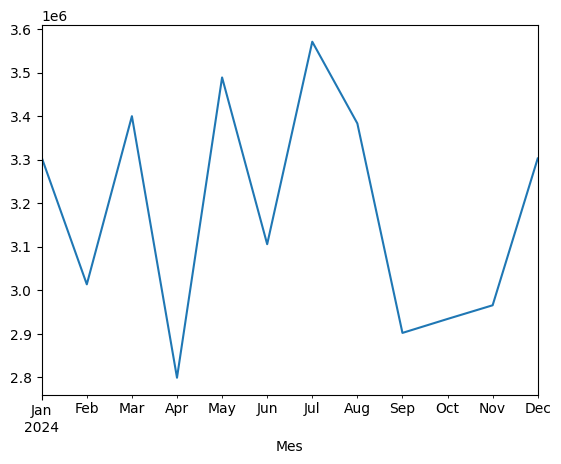

In [6]:
df["Mes"] = df["Data_Venda"].dt.to_period("M")

df.groupby("Mes")["Valor_Total"].sum().plot()
plt.show()

In [7]:
q1 = df["Valor_Total"].quantile(0.25)
q3 = df["Valor_Total"].quantile(0.75)

iqr = q3 - q1

outliers = df[
    (df["Valor_Total"] < (q1 - 1.5 * iqr)) |
    (df["Valor_Total"] > (q3 + 1.5 * iqr))
]

outliers.head()

,ID_Transacao,Data_Venda,ID_Cliente,Nome_Produto,Categoria_Produto,Valor_Unitario,Quantidade,Valor_Total,Mes
386,386,2024-02-20,142,Teclado,Periféricos,4983.10,5,24915.50,2024-02
652,652,2024-06-25,113,Teclado,Periféricos,4899.61,5,24498.05,2024-06
780,780,2024-07-05,735,Notebook,Hardware,4969.32,5,24846.60,2024-07
788,788,2024-04-05,697,Headset,Áudio,4872.46,5,24362.30,2024-04
1073,1073,2024-03-14,50,Teclado,Periféricos,4920.15,5,24600.75,2024-03


In [8]:
df[["Valor_Unitario", "Quantidade", "Valor_Total"]].corr()

,Valor_Unitario,Quantidade,Valor_Total
Valor_Unitario,1.000000,-0.004979,0.724922
Quantidade,-0.004979,1.000000,0.594866
Valor_Total,0.724922,0.594866,1.000000


In [9]:
rfm = df.groupby("ID_Cliente").agg({
    "Data_Venda": lambda x: (df["Data_Venda"].max() - x.max()).days,
    "ID_Transacao": "count",
    "Valor_Total": "sum"
})

rfm.columns = ["Recencia", "Frequencia", "Monetario"]

rfm.head()

,Recencia,Frequencia,Monetario
ID_Cliente,,,
1,9,11,73356.17
2,167,3,18450.04
3,19,3,16065.79
4,16,5,30048.68
5,31,6,53808.66
